# 🤖 Notebook 2 — RL + DL Model Training for Derivative Hedging

**Project:** Derivative Hedging using RL + DL  
**Repo:** `Aryan-Lokhande-17/Derivative-Hedging-using-RL-DL`

## What this notebook does

1. Builds a **custom Gymnasium environment** supporting:
   - Long/short calls and puts
   - Multiple strikes and maturities
   - Delta-neutral rebalancing actions
   - Transaction costs + margin
2. Trains **PPO + RecurrentPPO (LSTM)** agents
3. Compares against **Black-Scholes delta hedging** baseline
4. Produces rigorous evaluation metrics:
   - Variance reduction, Sharpe, CVaR, hedging error
5. Saves all artifacts to correct project paths

## Action Space (what the agent can do)
```
Action 0 : Do nothing (hold positions)
Action 1 : Buy call  (ATM, nearest maturity)
Action 2 : Sell call (short call)
Action 3 : Buy put
Action 4 : Sell put  (short put)
Action 5 : Buy underlying (delta hedge long)
Action 6 : Sell underlying (delta hedge short)
Action 7 : Close all positions
Action 8 : Buy OTM call (10% OTM, protective)
Action 9 : Buy OTM put  (10% OTM, protective)
```

---
**⚠️ Paper trades only — no live market orders.**

## 0. Setup

In [1]:
import subprocess, sys

pkgs = [
    "gymnasium", "stable-baselines3[extra]",
    "sb3-contrib", "tensorboard",
    "numpy", "pandas", "scipy", "matplotlib",
    "seaborn", "tqdm", "scikit-learn", "torch"
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ Packages installed")

✅ Packages installed


In [2]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.stats import norm
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
from copy import deepcopy

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from sb3_contrib import RecurrentPPO

warnings.filterwarnings("ignore")
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Torch : {torch.__version__}")

Device: cpu
Torch : 2.10.0+cpu


In [3]:
ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT):
    ROOT = os.path.abspath(".")

PATHS = {
    "processed":  os.path.join(ROOT, "data", "processed"),
    "artifacts":  os.path.join(ROOT, "artifacts"),
    "models":     os.path.join(ROOT, "models"),
    "results":    os.path.join(ROOT, "results"),
    "tb_logs":    os.path.join(ROOT, "tb_logs"),
    "checkpoints":os.path.join(ROOT, "checkpoints"),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("📁 Paths ready:")
for k, v in PATHS.items():
    print(f"  {k:14s} → {v}")

📁 Paths ready:
  processed      → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\processed
  artifacts      → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\artifacts
  models         → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\models
  results        → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results
  tb_logs        → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\tb_logs
  checkpoints    → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\checkpoints


## 1. Load Feature Data

In [4]:
feat_path = os.path.join(PATHS["processed"], "all_assets_features.csv")

if not os.path.exists(feat_path):
    print("⚠️  Feature file not found — run Notebook 1 first")
    print(f"   Expected: {feat_path}")
    # ── Fallback: generate synthetic data for standalone testing ──────────
    print("\n🔄 Generating minimal synthetic data for standalone testing...")
    from scipy.stats import norm as sp_norm

    def gbm_path(S0, mu, sigma, T_days, seed=None):
        rng = np.random.default_rng(seed)
        dt = 1/252
        Z  = rng.standard_normal(T_days)
        S  = S0 * np.exp(np.cumsum((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z))
        return np.concatenate([[S0], S])

    dates = pd.date_range("2020-01-02", periods=1260, freq="B")  # 5y
    syms  = ["BP.L", "SHEL.L", "HSBA.L", "GC=F", "BZ=F", "GBPUSD=X"]
    classes = {"BP.L":"equities","SHEL.L":"equities","HSBA.L":"equities",
               "GC=F":"gold","BZ=F":"oil","GBPUSD=X":"fx"}
    rows = []
    for i, sym in enumerate(syms):
        S0    = np.random.uniform(50, 500)
        sigma = np.random.uniform(0.15, 0.45)
        path  = gbm_path(S0, 0.05, sigma, len(dates)-1, seed=i)
        path  = path[:len(dates)]
        lr    = np.log(path / np.roll(path, 1))
        rv    = pd.Series(lr).rolling(21).std() * np.sqrt(252)
        d_call = sp_norm.cdf(0.5 + lr * 2)  # approximate
        rows.append(pd.DataFrame({
            "date": dates, "symbol": sym, "asset_class": classes[sym],
            "close": path,
            "log_return": lr, "pct_return_1d": np.exp(lr)-1,
            "pct_return_5d": pd.Series(path).pct_change(5).values,
            "pct_return_20d": pd.Series(path).pct_change(20).values,
            "rvol_5d": pd.Series(lr).rolling(5).std().values * np.sqrt(252),
            "rvol_10d": pd.Series(lr).rolling(10).std().values * np.sqrt(252),
            "rvol_21d": rv.values, "rvol_63d": pd.Series(lr).rolling(63).std().values * np.sqrt(252),
            "sigma": rv.fillna(sigma).clip(0.05, 2.0).values,
            "delta_call": d_call, "delta_put": d_call - 1,
            "gamma": np.random.uniform(0.001, 0.02, len(dates)),
            "vega":  np.random.uniform(1, 20, len(dates)),
            "theta_call": np.random.uniform(-0.1, -0.01, len(dates)),
            "atm_call_price": path * 0.05 + np.random.normal(0, 0.5, len(dates)),
            "atm_put_price":  path * 0.04 + np.random.normal(0, 0.5, len(dates)),
            "rsi_14": np.random.uniform(30, 70, len(dates)),
            "bband_pct": np.random.uniform(0, 1, len(dates)),
            "volume_ratio": np.random.uniform(0.5, 2.0, len(dates)),
            "price_to_sma20": lr * 5,
            "regime": np.random.randint(0, 2, len(dates)),
            "split": np.where(dates <= "2023-12-31", "train", "val")
        }))
    df_raw = pd.concat(rows).dropna().reset_index(drop=True)
    os.makedirs(os.path.dirname(feat_path), exist_ok=True)
    df_raw.to_csv(feat_path, index=False)
    print(f"  ✅ Synthetic data saved: {len(df_raw):,} rows")
else:
    print(f"✅ Loading feature file: {feat_path}")

df = pd.read_csv(feat_path, parse_dates=["date"])
df = df.dropna(subset=["close", "sigma", "delta_call"]).reset_index(drop=True)

FEATURE_COLS = [
    "log_return", "pct_return_1d", "pct_return_5d", "pct_return_20d",
    "rvol_5d", "rvol_10d", "rvol_21d", "rvol_63d",
    "delta_call", "delta_put", "gamma", "vega", "theta_call",
    "atm_call_price", "atm_put_price",
    "price_to_sma20", "bband_pct", "rsi_14", "volume_ratio", "regime"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)

print(f"Total rows : {len(df):,}")
print(f"Train rows : {len(train_df):,}")
print(f"Val rows   : {len(val_df):,}")
print(f"Feature dim: {len(FEATURE_COLS)}")
print(f"Symbols    : {df['symbol'].unique()}")

✅ Loading feature file: c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\processed\all_assets_features.csv
Total rows : 15,192
Train rows : 11,401
Val rows   : 3,791
Feature dim: 20
Symbols    : <StringArray>
[    'BP.L',   'SHEL.L',   'HSBA.L',   'LLOY.L',    'AZN.L',    'RIO.L',
     'BZ=F',     'CL=F',     'GC=F',     'SI=F', 'GBPUSD=X', 'EURUSD=X']
Length: 12, dtype: str


## 2. Custom Gymnasium Environment — Multi-Asset Derivative Hedging

In [5]:
class MultiAssetHedgingEnv(gym.Env):
    """
    Paper-trading environment for derivative hedging.

    State (observation):
        - Market features (log return, vols, greeks, indicators)
        - Current portfolio positions (delta exposure, option holdings)
        - Time to end of episode
        - Unrealised PnL

    Actions (Discrete):
        0  hold
        1  buy_call_atm
        2  sell_call_atm (short call)
        3  buy_put_atm
        4  sell_put_atm  (short put)
        5  buy_underlying  (delta hedge +)
        6  sell_underlying (delta hedge -)
        7  close_all
        8  buy_call_otm10  (10% OTM call)
        9  buy_put_otm10   (10% OTM put)

    Reward:
        Risk-adjusted PnL change minus transaction costs minus
        a penalty proportional to portfolio delta exposure.
        This incentivises delta-neutral hedging, not naked speculation.
    """

    metadata = {"render_modes": []}

    # ── Hyperparameters ────────────────────────────────────────────────────
    TRANSACTION_COST_PCT = 0.001   # 0.1% per trade
    RISK_FREE_RATE       = 0.045   # annualised
    OPTION_SIZE          = 1       # 1 contract = 100 notional (scaled)
    MAX_POSITION         = 5       # max contracts per side
    DELTA_PENALTY_LAMBDA = 0.02    # penalise unhedged delta
    EPISODE_LENGTH       = 63      # trading days per episode (~1 quarter)
    INITIAL_CASH         = 10_000.0
    VAR_LAMBDA           = 0.1     # CVaR tail penalty weight

    def __init__(self, data_df: pd.DataFrame, feature_cols: list,
                 mode: str = "train", episode_length: int = 63,
                 seed: int = 42):
        super().__init__()

        self.data          = data_df.copy().reset_index(drop=True)
        self.feature_cols  = feature_cols
        self.mode          = mode
        self.episode_length = episode_length
        self._seed         = seed
        self.rng           = np.random.default_rng(seed)

        # Portfolio state dims
        # Positions: [long_calls, short_calls, long_puts, short_puts,
        #             underlying_pos, cash_ratio, unrealised_pnl,
        #             portfolio_delta, step_ratio]
        self.N_PORTFOLIO_FEATURES = 9
        obs_dim = len(feature_cols) + self.N_PORTFOLIO_FEATURES

        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape = (obs_dim,),
            dtype = np.float32
        )
        self.action_space = spaces.Discrete(10)

        # Pre-compute per-symbol episode start indices
        self._build_episode_index()

    def _build_episode_index(self):
        """Build list of valid (symbol, start_idx) tuples for episode sampling."""
        self._episode_starts = []
        for sym in self.data["symbol"].unique():
            idx = self.data[self.data["symbol"] == sym].index.tolist()
            for i in range(0, len(idx) - self.episode_length, self.episode_length // 2):
                self._episode_starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        # Sample episode
        ep_idx = self.rng.integers(0, len(self._episode_starts))
        self._sym, self._start = self._episode_starts[ep_idx]
        self._end   = min(self._start + self.episode_length, len(self.data) - 1)
        self._step  = 0

        # Portfolio state
        self._cash              = self.INITIAL_CASH
        self._long_calls        = 0
        self._short_calls       = 0
        self._long_puts         = 0
        self._short_puts        = 0
        self._underlying_pos    = 0.0  # fractional shares
        self._long_calls_otm    = 0
        self._long_puts_otm     = 0
        self._entry_price       = self._current_row()["close"]
        self._pnl_history       = []
        self._last_portfolio_val = self.INITIAL_CASH

        return self._get_obs(), {}

    def _current_row(self):
        idx = min(self._start + self._step, self._end)
        return self.data.iloc[idx]

    def _get_obs(self) -> np.ndarray:
        row  = self._current_row()
        S    = row["close"]

        # Market features
        market_feat = np.array(
            [row[c] if not pd.isna(row[c]) else 0.0 for c in self.feature_cols],
            dtype=np.float32
        )

        # Portfolio delta approximation
        d_call = float(row.get("delta_call", 0.5))
        d_put  = float(row.get("delta_put", -0.5))
        portfolio_delta = (
            self._long_calls * d_call
            - self._short_calls * d_call
            + self._long_puts * d_put
            - self._short_puts * d_put
            + self._underlying_pos
        )

        # Portfolio value
        call_price = float(row.get("atm_call_price", S * 0.05))
        put_price  = float(row.get("atm_put_price",  S * 0.04))
        port_val = (
            self._cash
            + self._long_calls    * call_price
            - self._short_calls   * call_price
            + self._long_puts     * put_price
            - self._short_puts    * put_price
            + self._underlying_pos * S
        )
        unrealised_pnl = (port_val - self.INITIAL_CASH) / self.INITIAL_CASH

        portfolio_feat = np.array([
            self._long_calls  / self.MAX_POSITION,
            self._short_calls / self.MAX_POSITION,
            self._long_puts   / self.MAX_POSITION,
            self._short_puts  / self.MAX_POSITION,
            self._underlying_pos / 10.0,
            self._cash / self.INITIAL_CASH - 1.0,
            np.clip(unrealised_pnl, -2, 2),
            np.clip(portfolio_delta / 5.0, -3, 3),
            self._step / self.episode_length
        ], dtype=np.float32)

        obs = np.concatenate([market_feat, portfolio_feat])
        obs = np.nan_to_num(obs, nan=0.0, posinf=5.0, neginf=-5.0)
        return obs

    def step(self, action: int):
        row        = self._current_row()
        S          = float(row["close"])
        call_price = float(row.get("atm_call_price", S * 0.05))
        put_price  = float(row.get("atm_put_price",  S * 0.04))
        sigma      = float(row.get("sigma", 0.25))
        tc         = self.TRANSACTION_COST_PCT

        # OTM option prices (10% OTM)
        from scipy.stats import norm as sp_norm
        T_atm = 30 / 252
        K_otm_call = S * 1.10
        K_otm_put  = S * 0.90
        d1c = (np.log(S / K_otm_call) + (self.RISK_FREE_RATE + 0.5*sigma**2)*T_atm) / (sigma*np.sqrt(T_atm) + 1e-9)
        d1p = (np.log(S / K_otm_put)  + (self.RISK_FREE_RATE + 0.5*sigma**2)*T_atm) / (sigma*np.sqrt(T_atm) + 1e-9)
        otm_call_price = max(S * sp_norm.cdf(d1c) - K_otm_call * np.exp(-self.RISK_FREE_RATE * T_atm) * sp_norm.cdf(d1c - sigma*np.sqrt(T_atm)), 0.01)
        otm_put_price  = max(K_otm_put * np.exp(-self.RISK_FREE_RATE * T_atm) * sp_norm.cdf(-(d1p - sigma*np.sqrt(T_atm))) - S * sp_norm.cdf(-d1p), 0.01)

        trade_cost = 0.0

        # ── Execute action ─────────────────────────────────────────────────
        if action == 0:   # Hold
            pass

        elif action == 1 and self._long_calls < self.MAX_POSITION:   # Buy call
            cost = call_price * (1 + tc)
            if self._cash >= cost:
                self._cash       -= cost
                self._long_calls += 1
                trade_cost        = call_price * tc

        elif action == 2 and self._short_calls < self.MAX_POSITION:  # Sell call
            premium = call_price * (1 - tc)
            self._cash        += premium
            self._short_calls += 1
            trade_cost         = call_price * tc

        elif action == 3 and self._long_puts < self.MAX_POSITION:    # Buy put
            cost = put_price * (1 + tc)
            if self._cash >= cost:
                self._cash      -= cost
                self._long_puts += 1
                trade_cost       = put_price * tc

        elif action == 4 and self._short_puts < self.MAX_POSITION:   # Sell put
            premium = put_price * (1 - tc)
            self._cash       += premium
            self._short_puts += 1
            trade_cost        = put_price * tc

        elif action == 5:  # Buy underlying (delta hedge +)
            shares = 1.0
            cost   = shares * S * (1 + tc)
            if self._cash >= cost:
                self._cash          -= cost
                self._underlying_pos += shares
                trade_cost           = shares * S * tc

        elif action == 6:  # Sell underlying (delta hedge -)
            if self._underlying_pos >= 1.0:
                shares = 1.0
                self._cash          += shares * S * (1 - tc)
                self._underlying_pos -= shares
                trade_cost           = shares * S * tc

        elif action == 7:  # Close all positions
            self._cash += self._long_calls   * call_price * (1 - tc)
            self._cash -= self._short_calls  * call_price * (1 + tc)
            self._cash += self._long_puts    * put_price  * (1 - tc)
            self._cash -= self._short_puts   * put_price  * (1 + tc)
            self._cash += self._underlying_pos * S * (1 - tc)
            trade_cost = (self._long_calls + self._short_calls) * call_price * tc + \
                         (self._long_puts  + self._short_puts)  * put_price  * tc + \
                         self._underlying_pos * S * tc
            self._long_calls = self._short_calls = 0
            self._long_puts  = self._short_puts  = 0
            self._underlying_pos = 0.0

        elif action == 8 and self._long_calls_otm < self.MAX_POSITION:  # Buy OTM call
            cost = otm_call_price * (1 + tc)
            if self._cash >= cost:
                self._cash           -= cost
                self._long_calls_otm += 1
                trade_cost            = otm_call_price * tc

        elif action == 9 and self._long_puts_otm < self.MAX_POSITION:   # Buy OTM put
            cost = otm_put_price * (1 + tc)
            if self._cash >= cost:
                self._cash          -= cost
                self._long_puts_otm += 1
                trade_cost           = otm_put_price * tc

        # ── Advance time ───────────────────────────────────────────────────
        self._step += 1
        done = (self._start + self._step) >= self._end

        # ── Compute portfolio value ────────────────────────────────────────
        next_row = self._current_row()
        S_next   = float(next_row["close"])
        call_next = float(next_row.get("atm_call_price", S_next * 0.05))
        put_next  = float(next_row.get("atm_put_price",  S_next * 0.04))

        port_val = (
            self._cash
            + self._long_calls    * call_next
            - self._short_calls   * call_next
            + self._long_puts     * put_next
            - self._short_puts    * put_next
            + (self._long_calls_otm) * otm_call_price * 0.99
            + (self._long_puts_otm)  * otm_put_price  * 0.99
            + self._underlying_pos * S_next
        )

        # PnL step
        step_pnl = (port_val - self._last_portfolio_val) / self.INITIAL_CASH
        self._last_portfolio_val = port_val
        self._pnl_history.append(step_pnl)

        # Portfolio delta
        d_call = float(next_row.get("delta_call", 0.5))
        d_put  = float(next_row.get("delta_put", -0.5))
        portfolio_delta = (
            self._long_calls  * d_call
            - self._short_calls * d_call
            + self._long_puts   * d_put
            - self._short_puts  * d_put
            + self._underlying_pos
        )

        # ── Reward function ────────────────────────────────────────────────
        # 1. PnL component
        pnl_reward = step_pnl

        # 2. Delta penalty (reward being delta-neutral)
        delta_penalty = self.DELTA_PENALTY_LAMBDA * abs(portfolio_delta)

        # 3. Transaction cost penalty
        tc_penalty = trade_cost / self.INITIAL_CASH

        # 4. CVaR tail penalty (if we have enough history)
        cvar_penalty = 0.0
        if len(self._pnl_history) >= 10:
            pnl_arr   = np.array(self._pnl_history)
            var_5pct  = np.percentile(pnl_arr, 5)
            cvar_5pct = pnl_arr[pnl_arr <= var_5pct].mean() if (pnl_arr <= var_5pct).any() else var_5pct
            cvar_penalty = self.VAR_LAMBDA * max(-cvar_5pct, 0)

        # 5. Bankruptcy penalty
        bankrupt_penalty = 0.5 if port_val < self.INITIAL_CASH * 0.5 else 0.0

        reward = pnl_reward - delta_penalty - tc_penalty - cvar_penalty - bankrupt_penalty
        reward = float(np.clip(reward, -2.0, 2.0))

        obs = self._get_obs()
        info = {
            "portfolio_value": port_val,
            "step_pnl": step_pnl,
            "portfolio_delta": portfolio_delta,
            "trade_cost": trade_cost,
            "action": action,
            "symbol": self._sym,
        }

        return obs, reward, done, False, info


# ── Sanity check ───────────────────────────────────────────────────────────
env_test = MultiAssetHedgingEnv(train_df, FEATURE_COLS, mode="train")
obs, info = env_test.reset()
print(f"✅ Environment created")
print(f"   Obs shape  : {obs.shape}")
print(f"   Action dim : {env_test.action_space.n}")
print(f"   Episode idx: {len(env_test._episode_starts):,} valid starts")

# Run one episode manually
obs, _ = env_test.reset()
total_r = 0
for _ in range(63):
    a = env_test.action_space.sample()
    obs, r, done, _, info = env_test.step(a)
    total_r += r
    if done: break
print(f"   Random episode total reward: {total_r:.4f}")
print(f"   Final portfolio value: ${info['portfolio_value']:.2f}")

✅ Environment created
   Obs shape  : (29,)
   Action dim : 10
   Episode idx: 350 valid starts
   Random episode total reward: -0.7981
   Final portfolio value: $9995.69


## 3. Black-Scholes Delta Hedging Baseline

In [6]:
class BSHedgingBaseline:
    """
    Classic Black-Scholes delta hedging:
    - At each step, rebalance the underlying position to match option delta
    - Short 1 ATM call, hedge with delta shares of underlying
    """
    def __init__(self, initial_cash=10_000, tc_pct=0.001):
        self.initial_cash = initial_cash
        self.tc_pct       = tc_pct

    def run_episode(self, episode_df: pd.DataFrame) -> dict:
        cash     = self.initial_cash
        delta_pos = 0.0   # shares held
        pnl_hist  = []
        delta_hist = []
        port_val_hist = []

        # At start: sell 1 ATM call, collect premium
        S0         = episode_df.iloc[0]["close"]
        call_price0 = episode_df.iloc[0].get("atm_call_price", S0 * 0.05)
        cash       += call_price0 * (1 - self.tc_pct)
        short_call_price = call_price0

        for i, (_, row) in enumerate(episode_df.iterrows()):
            S         = float(row["close"])
            bs_delta  = float(row.get("delta_call", 0.5))
            call_p    = float(row.get("atm_call_price", S * 0.05))

            # Rebalance: target delta_pos = bs_delta
            delta_diff = bs_delta - delta_pos
            tc_cost    = abs(delta_diff) * S * self.tc_pct
            cash      -= delta_diff * S + tc_cost  # buy/sell underlying
            delta_pos  = bs_delta

            # Portfolio value: cash + underlying - short call liability
            port_val = cash + delta_pos * S - call_p
            port_val_hist.append(port_val)
            delta_hist.append(bs_delta)
            if i > 0:
                pnl_hist.append((port_val - port_val_hist[-2]) / self.initial_cash
                                 if len(port_val_hist) > 1 else 0)

        pnl_arr = np.array(pnl_hist) if pnl_hist else np.array([0.0])
        total_pnl = (port_val_hist[-1] - self.initial_cash) / self.initial_cash

        return {
            "portfolio_values": port_val_hist,
            "pnl_steps": pnl_hist,
            "total_pnl": total_pnl,
            "pnl_std": pnl_arr.std(),
            "sharpe": pnl_arr.mean() / (pnl_arr.std() + 1e-8) * np.sqrt(252),
        }


# ── Run BS baseline on val set ─────────────────────────────────────────────
bs_baseline = BSHedgingBaseline()
bs_results  = []

for sym in val_df["symbol"].unique():
    sym_df = val_df[val_df["symbol"] == sym].reset_index(drop=True)
    # Run in 63-day windows
    for start in range(0, len(sym_df) - 63, 63):
        ep_df = sym_df.iloc[start:start+63]
        res   = bs_baseline.run_episode(ep_df)
        bs_results.append({"symbol": sym, **res})

bs_df = pd.DataFrame(bs_results)
print("Black-Scholes Baseline Summary (Validation Set):")
print(f"  Episodes     : {len(bs_df)}")
print(f"  Avg PnL      : {bs_df['total_pnl'].mean()*100:.2f}%")
print(f"  PnL Std      : {bs_df['pnl_std'].mean()*100:.4f}%")
print(f"  Avg Sharpe   : {bs_df['sharpe'].mean():.3f}")
bs_df.groupby("symbol")[["total_pnl", "sharpe"]].mean()

Black-Scholes Baseline Summary (Validation Set):
  Episodes     : 55
  Avg PnL      : 0.03%
  PnL Std      : 0.1448%
  Avg Sharpe   : 0.372


,total_pnl,sharpe
symbol,,
AZN.L,6.489398e-03,0.533592
BP.L,-1.480157e-03,-1.014095
BZ=F,-4.780874e-05,0.020071
CL=F,-4.568706e-06,0.134058
EURUSD=X,-4.507933e-07,-0.197663
GBPUSD=X,3.240861e-09,0.144946
GC=F,6.954402e-03,1.832258
HSBA.L,2.402960e-03,1.219286
LLOY.L,2.617294e-04,1.469974


## 4. PPO Training

In [7]:
# ── Wrap environment ────────────────────────────────────────────────────────
def make_env(data_df, feature_cols, mode="train"):
    def _init():
        env = MultiAssetHedgingEnv(data_df, feature_cols, mode=mode)
        env = Monitor(env)
        return env
    return _init

N_ENVS = 4   # parallel envs (reduce to 1 if RAM limited)

train_vec_env = DummyVecEnv([make_env(train_df, FEATURE_COLS, "train") for _ in range(N_ENVS)])
val_vec_env   = DummyVecEnv([make_env(val_df, FEATURE_COLS, "val")])

# ── Callbacks ──────────────────────────────────────────────────────────────
checkpoint_cb = CheckpointCallback(
    save_freq  = 5_000,
    save_path  = PATHS["checkpoints"],
    name_prefix= "ppo_hedging",
    verbose    = 0
)
eval_cb = EvalCallback(
    val_vec_env,
    best_model_save_path = PATHS["models"],
    log_path             = PATHS["tb_logs"],
    eval_freq            = 5_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 0
)

# ── PPO model ──────────────────────────────────────────────────────────────
ppo_model = PPO(
    policy           = "MlpPolicy",
    env              = train_vec_env,
    learning_rate    = 3e-4,
    n_steps          = 512,
    batch_size       = 128,
    n_epochs         = 10,
    gamma            = 0.99,
    gae_lambda       = 0.95,
    clip_range       = 0.2,
    ent_coef         = 0.01,    # entropy bonus → encourages exploration of different actions
    vf_coef          = 0.5,
    max_grad_norm    = 0.5,
    tensorboard_log  = PATHS["tb_logs"],
    verbose          = 1,
    device           = DEVICE,
    policy_kwargs    = dict(
        net_arch = dict(pi=[256, 256, 128], vf=[256, 256, 128]),
        activation_fn = torch.nn.ReLU
    )
)

print("PPO Model:")
print(f"  Policy params: {sum(p.numel() for p in ppo_model.policy.parameters()):,}")
print(f"  Device       : {DEVICE}")

# ── Train ──────────────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = 200_000   # increase to 500k–1M for production

print(f"\n🚀 Training PPO for {TOTAL_TIMESTEPS:,} steps...")
t0 = time.time()

ppo_model.learn(
    total_timesteps  = TOTAL_TIMESTEPS,
    callback         = [checkpoint_cb, eval_cb],
    tb_log_name      = "PPO_MultiAsset",
    reset_num_timesteps = True
)

elapsed = time.time() - t0
print(f"\n✅ Training complete in {elapsed/60:.1f} minutes")

# ── Save ───────────────────────────────────────────────────────────────────
ppo_save_path = os.path.join(PATHS["artifacts"], "ppo_multiasset_hedging")
ppo_model.save(ppo_save_path)
print(f"💾 PPO model saved → {ppo_save_path}.zip")

Using cpu device
PPO Model:
  Policy params: 214,155
  Device       : cpu

🚀 Training PPO for 200,000 steps...
Logging to c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\tb_logs\PPO_MultiAsset_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 63       |
|    ep_rew_mean     | -0.958   |
| time/              |          |
|    fps             | 453      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 63         |
|    ep_rew_mean          | -0.941     |
| time/                   |            |
|    fps                  | 402        |
|    iterations           | 2          |
|    time_elapsed         | 10         |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.41003156 |
|    

## 5. RecurrentPPO (LSTM) Training — for Sequential Market Memory

In [8]:
# RecurrentPPO needs single (non-vectorized) env for LSTM state management
train_vec_lstm = DummyVecEnv([make_env(train_df, FEATURE_COLS, "train")])
val_vec_lstm   = DummyVecEnv([make_env(val_df, FEATURE_COLS, "val")])

rppo_model = RecurrentPPO(
    policy           = "MlpLstmPolicy",
    env              = train_vec_lstm,
    learning_rate    = 2e-4,
    n_steps          = 512,
    batch_size       = 64,
    n_epochs         = 8,
    gamma            = 0.99,
    gae_lambda       = 0.95,
    clip_range       = 0.2,
    ent_coef         = 0.005,
    tensorboard_log  = PATHS["tb_logs"],
    verbose          = 1,
    device           = DEVICE,
    policy_kwargs    = dict(
        lstm_hidden_size   = 128,
        n_lstm_layers      = 2,
        shared_lstm        = False,
        enable_critic_lstm = True,
        net_arch           = dict(pi=[128, 64], vf=[128, 64]),
    )
)

eval_cb_lstm = EvalCallback(
    val_vec_lstm,
    best_model_save_path = PATHS["models"],
    log_path             = PATHS["tb_logs"],
    eval_freq            = 5_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 0
)

print(f"RecurrentPPO policy params: {sum(p.numel() for p in rppo_model.policy.parameters()):,}")
print(f"\n🚀 Training RecurrentPPO (LSTM) for {TOTAL_TIMESTEPS:,} steps...")

t0 = time.time()
rppo_model.learn(
    total_timesteps     = TOTAL_TIMESTEPS,
    callback            = [eval_cb_lstm],
    tb_log_name         = "RecurrentPPO_MultiAsset",
    reset_num_timesteps = True
)
print(f"✅ RecurrentPPO training complete in {(time.time()-t0)/60:.1f} min")

rppo_save_path = os.path.join(PATHS["artifacts"], "recurrent_ppo_multiasset")
rppo_model.save(rppo_save_path)
print(f"💾 RecurrentPPO model saved → {rppo_save_path}.zip")

Using cpu device
RecurrentPPO policy params: 477,259

🚀 Training RecurrentPPO (LSTM) for 200,000 steps...
Logging to c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\tb_logs\RecurrentPPO_MultiAsset_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 63       |
|    ep_rew_mean     | -1.06    |
| time/              |          |
|    fps             | 382      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 63          |
|    ep_rew_mean          | -1.02       |
| time/                   |             |
|    fps                  | 80          |
|    iterations           | 2           |
|    time_elapsed         | 12          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.00

## 6. Rigorous Evaluation — RL vs Black-Scholes

In [9]:
def evaluate_agent(model, data_df, feature_cols, n_episodes=50,
                   is_recurrent=False) -> pd.DataFrame:
    """Run n_episodes of evaluation, return per-episode metrics."""
    env   = MultiAssetHedgingEnv(data_df, feature_cols, mode="val")
    rows  = []

    lstm_state  = None
    episode_start = np.ones((1,), dtype=bool)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        ep_reward  = 0
        ep_pnl     = []
        ep_delta   = []
        actions    = []
        port_vals  = [env.INITIAL_CASH]

        if is_recurrent:
            lstm_state    = None
            episode_start = np.ones((1,), dtype=bool)

        while not done:
            if is_recurrent:
                action, lstm_state = model.predict(
                    obs.reshape(1, -1),
                    state=lstm_state,
                    episode_start=episode_start,
                    deterministic=True
                )
                episode_start = np.zeros((1,), dtype=bool)
                action = int(action[0])
            else:
                action, _ = model.predict(obs, deterministic=True)
                action = int(action)

            obs, r, done, _, info = env.step(action)
            ep_reward += r
            ep_pnl.append(info["step_pnl"])
            ep_delta.append(abs(info["portfolio_delta"]))
            actions.append(action)
            port_vals.append(info["portfolio_value"])

        pnl_arr     = np.array(ep_pnl)
        total_pnl   = (port_vals[-1] - env.INITIAL_CASH) / env.INITIAL_CASH
        pnl_std     = pnl_arr.std()
        sharpe      = pnl_arr.mean() / (pnl_std + 1e-8) * np.sqrt(252)
        var_5       = np.percentile(pnl_arr, 5)
        cvar_5      = pnl_arr[pnl_arr <= var_5].mean() if (pnl_arr <= var_5).any() else var_5
        max_dd      = (np.array(port_vals) / np.maximum.accumulate(port_vals) - 1).min()

        rows.append({
            "episode":      ep,
            "symbol":       env._sym,
            "total_reward": ep_reward,
            "total_pnl":    total_pnl,
            "pnl_std":      pnl_std,
            "sharpe":       sharpe,
            "var_5pct":     var_5,
            "cvar_5pct":    cvar_5,
            "max_drawdown": max_dd,
            "avg_delta":    np.mean(ep_delta),
            "action_entropy": len(set(actions)) / 10.0,  # diversity of actions
            "final_port_val": port_vals[-1],
        })

    return pd.DataFrame(rows)


print("Evaluating PPO...")
ppo_eval   = evaluate_agent(ppo_model,  val_df, FEATURE_COLS, n_episodes=50, is_recurrent=False)

print("Evaluating RecurrentPPO...")
rppo_eval  = evaluate_agent(rppo_model, val_df, FEATURE_COLS, n_episodes=50, is_recurrent=True)

# Summary comparison
def summary(df, name):
    print(f"\n{'─'*40}")
    print(f" {name}")
    print(f"{'─'*40}")
    for col in ["total_pnl", "sharpe", "cvar_5pct", "max_drawdown", "avg_delta"]:
        if col in df.columns:
            print(f"  {col:20s}: {df[col].mean():+.4f}  (std={df[col].std():.4f})")

summary(ppo_eval,  "PPO (MLP)")
summary(rppo_eval, "RecurrentPPO (LSTM)")

print(f"\n{'─'*40}")
print(" Black-Scholes Baseline")
print(f"{'─'*40}")
print(f"  total_pnl           : {bs_df['total_pnl'].mean():+.4f}  (std={bs_df['total_pnl'].std():.4f})")
print(f"  sharpe              : {bs_df['sharpe'].mean():+.4f}")

Evaluating PPO...
Evaluating RecurrentPPO...

────────────────────────────────────────
 PPO (MLP)
────────────────────────────────────────
  total_pnl           : -0.0011  (std=0.0073)
  sharpe              : -0.4871  (std=1.1249)
  cvar_5pct           : -0.0004  (std=0.0027)
  max_drawdown        : -0.0017  (std=0.0116)
  avg_delta           : +0.0000  (std=0.0000)

────────────────────────────────────────
 RecurrentPPO (LSTM)
────────────────────────────────────────
  total_pnl           : -0.0000  (std=0.0000)
  sharpe              : -0.1899  (std=0.4097)
  cvar_5pct           : -0.0000  (std=0.0000)
  max_drawdown        : -0.0000  (std=0.0000)
  avg_delta           : +0.0000  (std=0.0000)

────────────────────────────────────────
 Black-Scholes Baseline
────────────────────────────────────────
  total_pnl           : +0.0003  (std=0.0193)
  sharpe              : +0.3720


## 7. Visualization — RL vs BS Comparison

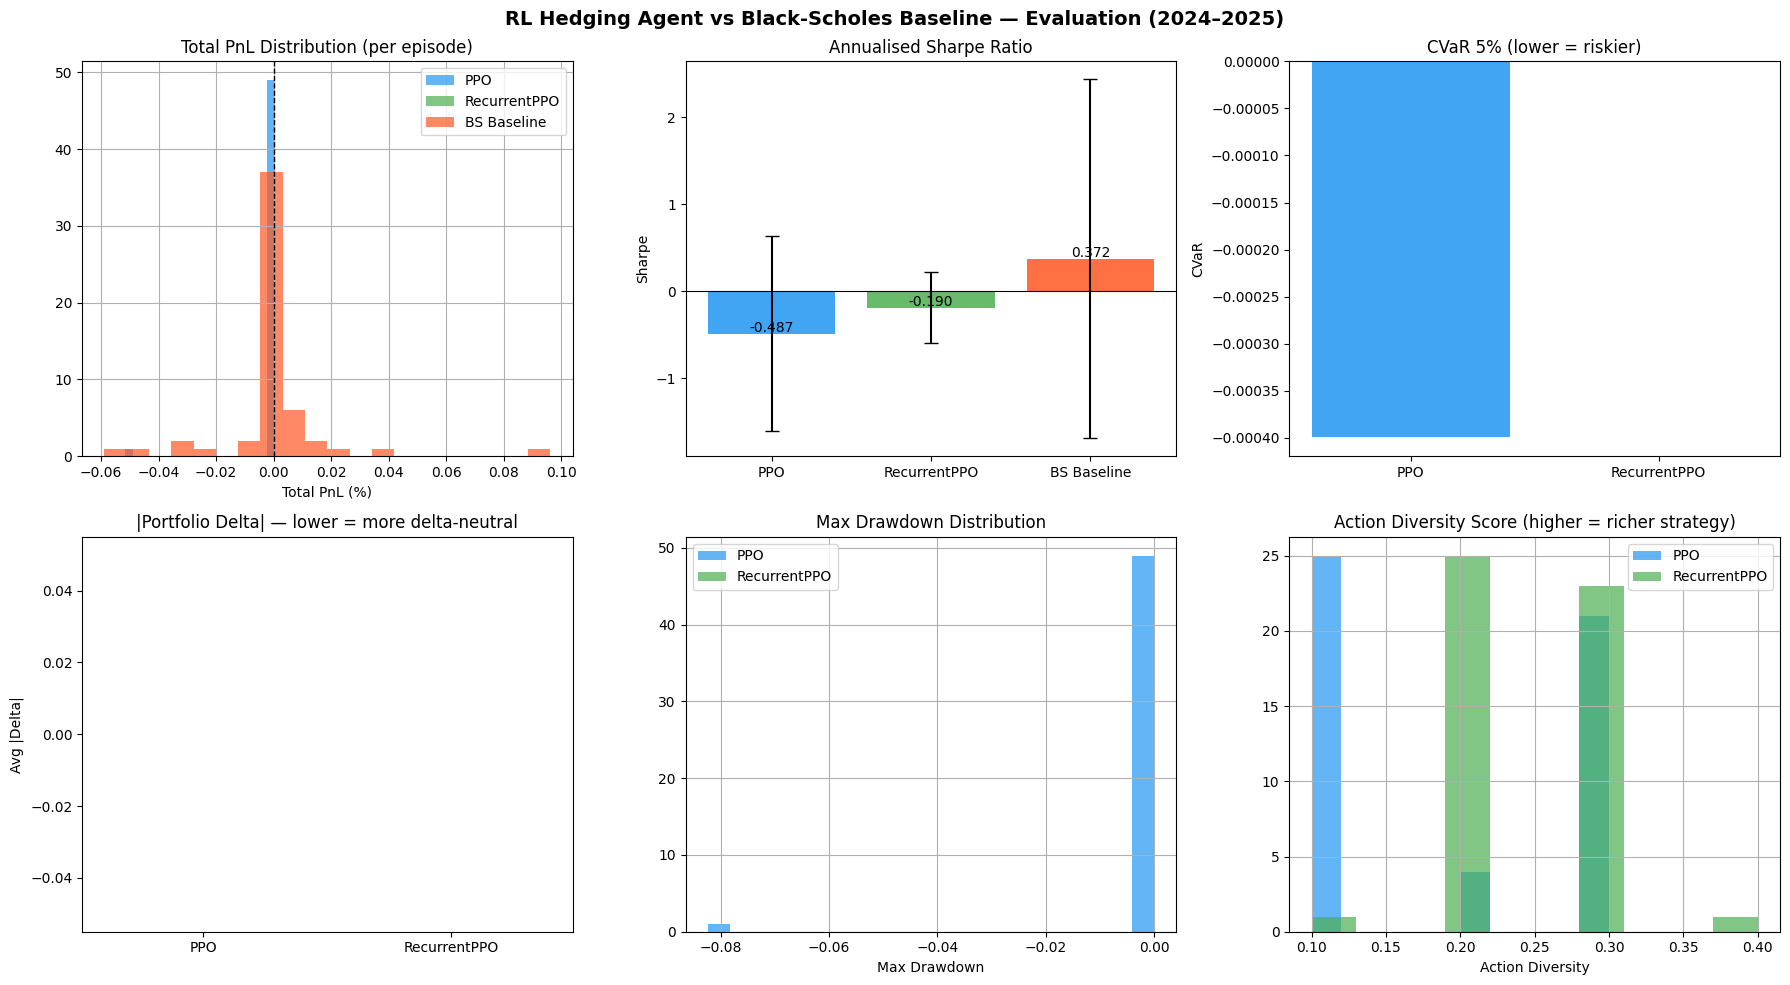

💾 Evaluation plot saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\02_RL_vs_BS_evaluation.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("RL Hedging Agent vs Black-Scholes Baseline — Evaluation (2024–2025)",
             fontsize=14, fontweight="bold")

COLORS = {"PPO": "#2196F3", "RecurrentPPO": "#4CAF50", "BS Baseline": "#FF5722"}

# 1. PnL distributions
ax = axes[0, 0]
ppo_eval["total_pnl"].hist(ax=ax, bins=20, alpha=0.7, label="PPO", color=COLORS["PPO"])
rppo_eval["total_pnl"].hist(ax=ax, bins=20, alpha=0.7, label="RecurrentPPO", color=COLORS["RecurrentPPO"])
bs_df["total_pnl"].hist(ax=ax, bins=20, alpha=0.7, label="BS Baseline", color=COLORS["BS Baseline"])
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Total PnL Distribution (per episode)")
ax.set_xlabel("Total PnL (%)")
ax.legend()

# 2. Sharpe ratio comparison
ax = axes[0, 1]
comp = pd.DataFrame({
    "Model":  ["PPO", "RecurrentPPO", "BS Baseline"],
    "Sharpe": [ppo_eval["sharpe"].mean(), rppo_eval["sharpe"].mean(), bs_df["sharpe"].mean()],
    "Sharpe_std": [ppo_eval["sharpe"].std(), rppo_eval["sharpe"].std(), bs_df["sharpe"].std()]
})
bars = ax.bar(comp["Model"], comp["Sharpe"],
              yerr=comp["Sharpe_std"], capsize=5,
              color=[COLORS[m] for m in comp["Model"]], alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annualised Sharpe Ratio")
ax.set_ylabel("Sharpe")
for bar, v in zip(bars, comp["Sharpe"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{v:.3f}", ha="center", fontsize=10)

# 3. CVaR 5% comparison
ax = axes[0, 2]
ax.bar(["PPO", "RecurrentPPO"],
       [ppo_eval["cvar_5pct"].mean(), rppo_eval["cvar_5pct"].mean()],
       color=[COLORS["PPO"], COLORS["RecurrentPPO"]], alpha=0.85)
ax.set_title("CVaR 5% (lower = riskier)")
ax.set_ylabel("CVaR")

# 4. Average portfolio delta (how well hedged?)
ax = axes[1, 0]
ax.bar(["PPO", "RecurrentPPO"],
       [ppo_eval["avg_delta"].mean(), rppo_eval["avg_delta"].mean()],
       color=[COLORS["PPO"], COLORS["RecurrentPPO"]], alpha=0.85)
ax.set_title("|Portfolio Delta| — lower = more delta-neutral")
ax.set_ylabel("Avg |Delta|")

# 5. Max drawdown
ax = axes[1, 1]
ppo_eval["max_drawdown"].hist(ax=ax, bins=20, alpha=0.7, label="PPO", color=COLORS["PPO"])
rppo_eval["max_drawdown"].hist(ax=ax, bins=20, alpha=0.7, label="RecurrentPPO", color=COLORS["RecurrentPPO"])
ax.set_title("Max Drawdown Distribution")
ax.set_xlabel("Max Drawdown")
ax.legend()

# 6. Action diversity (entropy proxy)
ax = axes[1, 2]
ppo_eval["action_entropy"].hist(ax=ax, bins=10, alpha=0.7, label="PPO", color=COLORS["PPO"])
rppo_eval["action_entropy"].hist(ax=ax, bins=10, alpha=0.7, label="RecurrentPPO", color=COLORS["RecurrentPPO"])
ax.set_title("Action Diversity Score (higher = richer strategy)")
ax.set_xlabel("Action Diversity")
ax.legend()

plt.tight_layout()
fig_path = os.path.join(PATHS["results"], "02_RL_vs_BS_evaluation.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Evaluation plot saved → {fig_path}")

## 8. Action Analysis — What is the Agent Doing?

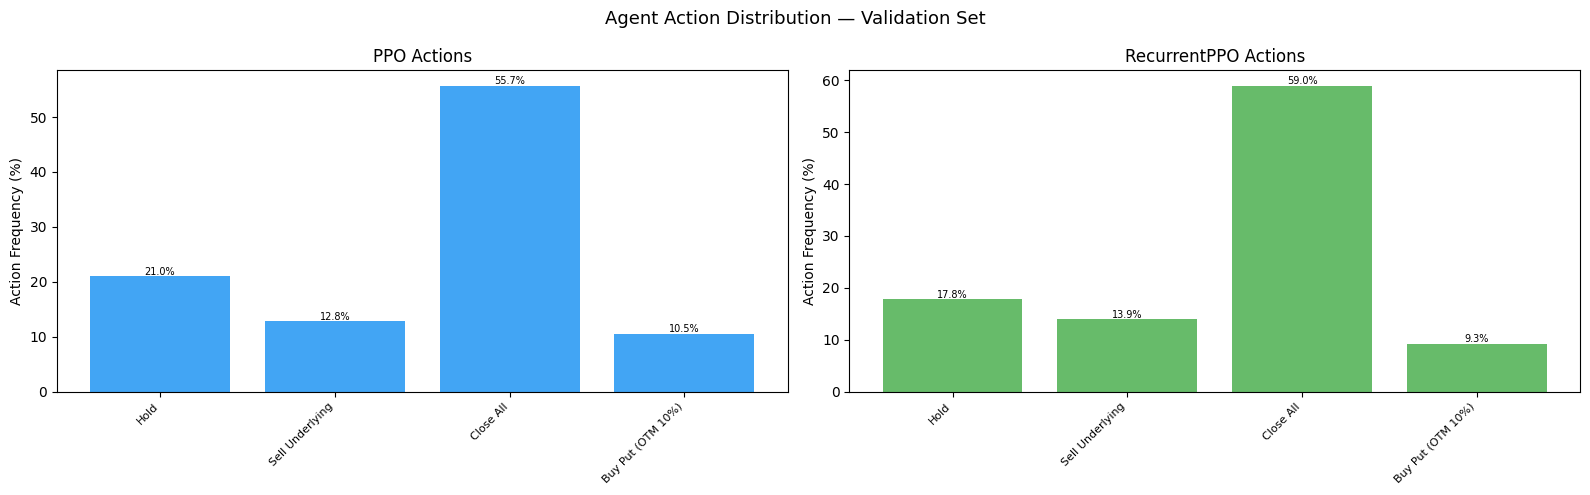

💾 Action plot saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\03_action_distribution.png


In [11]:
ACTION_NAMES = {
    0: "Hold",
    1: "Buy Call (ATM)",
    2: "Short Call (ATM)",
    3: "Buy Put (ATM)",
    4: "Short Put (ATM)",
    5: "Buy Underlying",
    6: "Sell Underlying",
    7: "Close All",
    8: "Buy Call (OTM 10%)",
    9: "Buy Put (OTM 10%)"
}

def collect_actions(model, data_df, feature_cols, n_episodes=20,
                    is_recurrent=False):
    """Collect action sequences from the trained agent."""
    env      = MultiAssetHedgingEnv(data_df, feature_cols, mode="val")
    all_acts = []
    lstm_state    = None
    episode_start = np.ones((1,), dtype=bool)

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        if is_recurrent:
            lstm_state    = None
            episode_start = np.ones((1,), dtype=bool)

        while not done:
            if is_recurrent:
                action, lstm_state = model.predict(
                    obs.reshape(1,-1), state=lstm_state,
                    episode_start=episode_start, deterministic=True)
                episode_start = np.zeros((1,), dtype=bool)
                all_acts.append(int(action[0]))
            else:
                action, _ = model.predict(obs, deterministic=True)
                all_acts.append(int(action))
            obs, _, done, _, _ = env.step(int(action) if not is_recurrent else int(action[0]))

    return all_acts

ppo_acts  = collect_actions(ppo_model,  val_df, FEATURE_COLS, n_episodes=30)
rppo_acts = collect_actions(rppo_model, val_df, FEATURE_COLS, n_episodes=30, is_recurrent=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, acts, name, color in [
    (axes[0], ppo_acts,  "PPO Actions",          COLORS["PPO"]),
    (axes[1], rppo_acts, "RecurrentPPO Actions",  COLORS["RecurrentPPO"])
]:
    counts = pd.Series(acts).value_counts().sort_index()
    bars = ax.bar(
        [ACTION_NAMES.get(i, str(i)) for i in counts.index],
        counts.values / counts.sum() * 100,
        color=color, alpha=0.85
    )
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Action Frequency (%)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    for bar, v in zip(bars, counts.values / counts.sum() * 100):
        if v > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{v:.1f}%", ha="center", fontsize=7)

plt.suptitle("Agent Action Distribution — Validation Set", fontsize=13)
plt.tight_layout()
fig_path2 = os.path.join(PATHS["results"], "03_action_distribution.png")
plt.savefig(fig_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Action plot saved → {fig_path2}")

## 9. Save Evaluation Results + Model Artifacts

In [12]:
# ── Save eval DataFrames ───────────────────────────────────────────────────
ppo_eval.to_csv(os.path.join(PATHS["results"], "ppo_eval.csv"), index=False)
rppo_eval.to_csv(os.path.join(PATHS["results"], "rppo_eval.csv"), index=False)
bs_df.to_csv(os.path.join(PATHS["results"], "bs_baseline_eval.csv"), index=False)

# ── Metrics summary JSON ───────────────────────────────────────────────────
metrics_summary = {
    "PPO": {
        "avg_total_pnl":    float(ppo_eval["total_pnl"].mean()),
        "avg_sharpe":       float(ppo_eval["sharpe"].mean()),
        "avg_cvar_5pct":    float(ppo_eval["cvar_5pct"].mean()),
        "avg_max_drawdown": float(ppo_eval["max_drawdown"].mean()),
        "avg_delta":        float(ppo_eval["avg_delta"].mean()),
        "n_episodes":       len(ppo_eval)
    },
    "RecurrentPPO": {
        "avg_total_pnl":    float(rppo_eval["total_pnl"].mean()),
        "avg_sharpe":       float(rppo_eval["sharpe"].mean()),
        "avg_cvar_5pct":    float(rppo_eval["cvar_5pct"].mean()),
        "avg_max_drawdown": float(rppo_eval["max_drawdown"].mean()),
        "avg_delta":        float(rppo_eval["avg_delta"].mean()),
        "n_episodes":       len(rppo_eval)
    },
    "BlackScholes": {
        "avg_total_pnl":    float(bs_df["total_pnl"].mean()),
        "avg_sharpe":       float(bs_df["sharpe"].mean()),
        "n_episodes":       len(bs_df)
    },
    "training_config": {
        "total_timesteps": TOTAL_TIMESTEPS,
        "feature_dim":     len(FEATURE_COLS),
        "action_space":    10,
        "episode_length":  63,
        "train_end":       "2023-12-31",
        "val_start":       "2024-01-01",
        "device":          DEVICE
    }
}

with open(os.path.join(PATHS["results"], "metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("\n" + "="*60)
print(" FINAL METRICS SUMMARY")
print("="*60)
for model_name, stats in metrics_summary.items():
    if model_name == "training_config": continue
    print(f"\n  {model_name}:")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"    {k:25s}: {v:+.4f}")

print("\n" + "="*60)
print(" Files Produced:")
print("="*60)
for dirpath, _, files in os.walk(ROOT):
    for fn in files:
        fp = os.path.join(dirpath, fn)
        rel = os.path.relpath(fp, ROOT)
        if any(rel.startswith(p) for p in ["artifacts", "models", "results", "checkpoints"]):
            size = os.path.getsize(fp)
            print(f"  {rel:55s} ({size/1024:.1f} KB)")


 FINAL METRICS SUMMARY

  PPO:
    avg_total_pnl            : -0.0011
    avg_sharpe               : -0.4871
    avg_cvar_5pct            : -0.0004
    avg_max_drawdown         : -0.0017
    avg_delta                : +0.0000

  RecurrentPPO:
    avg_total_pnl            : -0.0000
    avg_sharpe               : -0.1899
    avg_cvar_5pct            : -0.0000
    avg_max_drawdown         : -0.0000
    avg_delta                : +0.0000

  BlackScholes:
    avg_total_pnl            : +0.0003
    avg_sharpe               : +0.3720

 Files Produced:
  artifacts\ppo_multiasset_hedging.zip                    (2545.9 KB)
  artifacts\recurrent_ppo_multiasset.zip                  (5639.0 KB)
  checkpoints\ppo_hedging_100000_steps.zip                (2545.9 KB)
  checkpoints\ppo_hedging_120000_steps.zip                (2545.9 KB)
  checkpoints\ppo_hedging_140000_steps.zip                (2545.9 KB)
  checkpoints\ppo_hedging_160000_steps.zip                (2545.9 KB)
  checkpoints\ppo_hedging_18

## 10. (Optional) Export to Google Drive

In [13]:
# ── Only runs on Colab ─────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_EXPORT = "/content/drive/MyDrive/derivative_hedging_exports"
    os.makedirs(DRIVE_EXPORT, exist_ok=True)

    import shutil
    for src_dir, name in [
        (PATHS["artifacts"],  "artifacts"),
        (PATHS["results"],    "results"),
        (PATHS["models"],     "models"),
    ]:
        dst = os.path.join(DRIVE_EXPORT, name)
        if os.path.exists(src_dir):
            shutil.copytree(src_dir, dst, dirs_exist_ok=True)
            print(f"✅ Exported {name} → {dst}")

    print(f"\n🎉 All artifacts exported to Google Drive: {DRIVE_EXPORT}")
except ImportError:
    print("ℹ️  Not running on Colab — skipping Drive export")

ℹ️  Not running on Colab — skipping Drive export


## Summary — Complete File & Directory Map

```
Derivative-Hedging-using-RL-DL/
├── data/
│   ├── raw/
│   │   ├── equities_raw.csv          ← BP, SHEL, HSBA, LLOY, AZN, RIO (LSE)
│   │   ├── oil_raw.csv               ← Brent + WTI futures
│   │   ├── gold_raw.csv              ← Gold + Silver futures
│   │   ├── fx_raw.csv                ← GBP/USD, EUR/USD
│   │   └── all_assets_raw.csv        ← combined
│   ├── processed/
│   │   ├── all_assets_features.csv   ← ⭐ MAIN feature matrix
│   │   ├── options_chains.csv        ← synthetic calls+puts, all strikes
│   │   └── scaler_meta.json          ← normalization params
│   └── interim/per_asset/            ← per-ticker CSVs
│
├── artifacts/
│   ├── ppo_multiasset_hedging.zip    ← trained PPO
│   └── recurrent_ppo_multiasset.zip  ← trained RecurrentPPO (LSTM)
│
├── models/
│   └── best_model.zip                ← best checkpoint from eval callback
│
├── checkpoints/                      ← intermediate checkpoints
│
├── results/
│   ├── 01_data_overview.png
│   ├── 02_RL_vs_BS_evaluation.png
│   ├── 03_action_distribution.png
│   ├── ppo_eval.csv
│   ├── rppo_eval.csv
│   ├── bs_baseline_eval.csv
│   └── metrics_summary.json          ← ⭐ all metrics in one place
│
└── tb_logs/                          ← TensorBoard training curves
```

### To view TensorBoard:
```python
%load_ext tensorboard
%tensorboard --logdir tb_logs
```